# 01 Model Validation: AlphaGenome Captures Constraint at Gene Level figures

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = 'final_figure'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [3]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [4]:
real_variant_dfs = []
synth_variant_dfs = []

for key, path in VARIANT_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_variant_dfs.append(lf)
    else:
        real_variant_dfs.append(lf)

df_real = pl.concat(real_variant_dfs).collect()
df_synth = pl.concat(synth_variant_dfs).collect()

df_hi_variants = df_real.filter(pl.col('source') == 'clingen')
df_bg_variants = df_real.filter(pl.col('source') == 'background')
df_hi_synth_variants = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth_variants = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi_variants.height} variants')
print(f'Background: {df_bg_variants.height} variants')
print(f'ClinGen HI (Synth): {df_hi_synth_variants.height} variants')
print(f'Background (Synth): {df_bg_synth_variants.height} variants')

ClinGen HI: 1743183 variants
Background: 1999142 variants
ClinGen HI (Synth): 1556962 variants
Background (Synth): 1788286 variants


# Extra paths

In [5]:
GENE_CHARACTERISTICS = "/Users/markus/in-silico-vg-analysis/07_permutations/gene_characteristics.tsv"

Spearman ρ = 0.398,  P = 3.14e-25  (N = 627)
[save_plot] Saved: final_figure_Fig_LOEUF_vs_Vg_constraint_validation_14032026_1230.pdf
[save_plot] Saved: final_figure_Fig_LOEUF_vs_Vg_constraint_validation_14032026_1230.svg


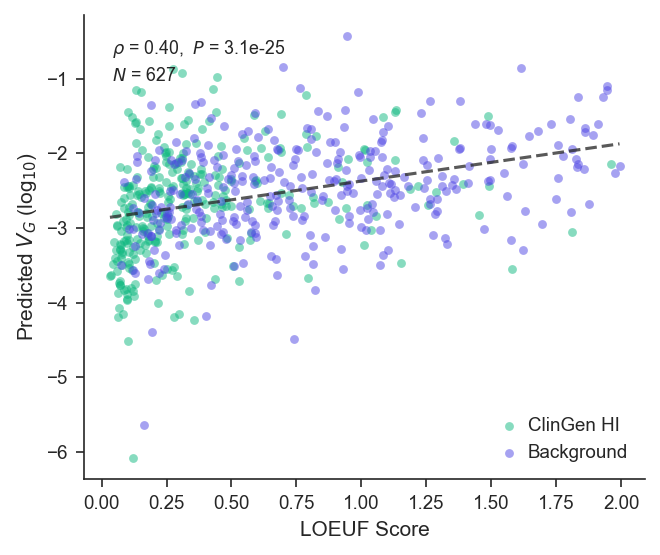

In [6]:

# ── Fig: Vg_predicted vs LOEUF — biological constraint validation ─────────────
# Uses df_hi / df_bg (gene-level, set in the gene-loading cell above)

_loeuf_df = (
    pl.concat([df_hi, df_bg])
    .select(['loeuf_score', 'vg_predicted', 'source'])
    .drop_nulls()
    .to_pandas()
)

rho, pval = stats.spearmanr(_loeuf_df['loeuf_score'], _loeuf_df['vg_predicted'])
print(f'Spearman ρ = {rho:.3f},  P = {pval:.2e}  (N = {len(_loeuf_df)})')

with autosave('Fig_LOEUF_vs_Vg_constraint_validation', notebook=NOTEBOOK_NAME):
    with sns.axes_style('ticks'):
        fig, ax = plt.subplots(figsize=(4.5, 3.8))

        for src in ['clingen', 'background']:
            sub = _loeuf_df[_loeuf_df['source'] == src]
            ax.scatter(
                sub['loeuf_score'],
                np.log10(np.maximum(sub['vg_predicted'].values, 1e-12)),
                color=SOURCE_PALETTE[src],
                alpha=0.5, s=18, linewidths=0,
                label=DISPLAY_NAMES[src],
                rasterized=True,
            )

        # Pooled OLS regression line
        _x = _loeuf_df['loeuf_score'].values
        _y = np.log10(np.maximum(_loeuf_df['vg_predicted'].values, 1e-12))
        _m, _b = np.polyfit(_x, _y, 1)
        _xs = np.linspace(_x.min(), _x.max(), 300)
        ax.plot(_xs, _m * _xs + _b, color='#222222', lw=1.5, ls='--', alpha=0.75, zorder=3)

        ax.text(
            0.05, 0.95,
            f'$\\rho$ = {rho:.2f},  $P$ = {pval:.1e}\n$N$ = {len(_loeuf_df):,}',
            transform=ax.transAxes, va='top', ha='left', fontsize=8.5,
            linespacing=1.5,
        )

        ax.set_xlabel('LOEUF Score', fontsize=10)
        ax.set_ylabel('Predicted $V_G$ (log$_{10}$)', fontsize=10)
        ax.tick_params(labelsize=9, direction='out', length=4)
        ax.legend(frameon=False, fontsize=9, handlelength=1.2, handletextpad=0.4)
        sns.despine(ax=ax)
        plt.tight_layout()


[save_plot] Saved: final_figure_Fig_LOEUF_decile_vs_Vg_14032026_1230.pdf
[save_plot] Saved: final_figure_Fig_LOEUF_decile_vs_Vg_14032026_1230.svg


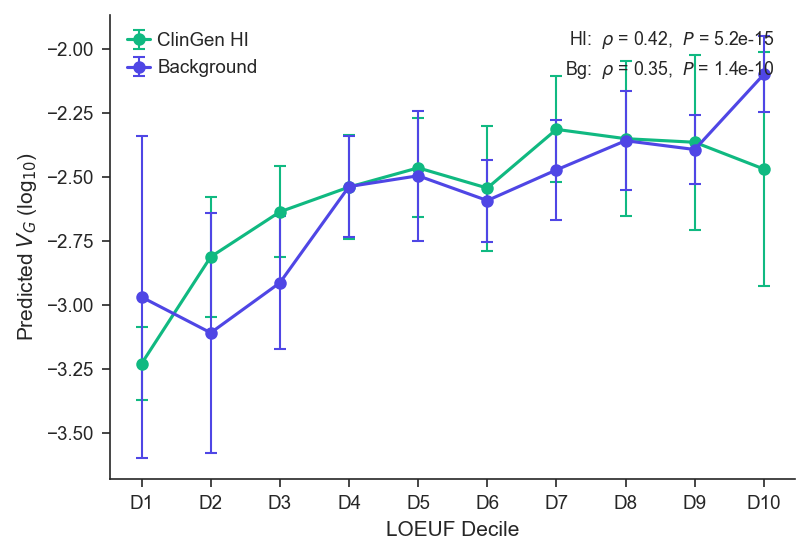

In [7]:
# ── Fig: Vg_predicted vs LOEUF — binned by 10 deciles ────────────────────────
_dec_df = (
    pl.concat([df_hi, df_bg])
    .select(['loeuf_score', 'vg_predicted', 'source'])
    .drop_nulls()
    .to_pandas()
)

# Bin pooled LOEUF into 10 equal-frequency deciles
_, _edges = pd.qcut(_dec_df['loeuf_score'], q=10, retbins=True)
_dec_df['decile'] = pd.qcut(_dec_df['loeuf_score'], q=10, labels=False) + 1  # 1–10
_dec_df['log_vg'] = np.log10(np.maximum(_dec_df['vg_predicted'].values, 1e-12))

# Spearman correlation per source (on raw gene-level data)
_stats = {}
for src in ['clingen', 'background']:
    _s = _dec_df[_dec_df['source'] == src]
    _rho, _p = stats.spearmanr(_s['loeuf_score'], _s['log_vg'])
    _stats[src] = (_rho, _p, len(_s))

# Aggregate: mean ± 95 % CI (±1.96 SEM)
_agg = (
    _dec_df.groupby(['source', 'decile'])['log_vg']
    .agg(['mean', 'sem'])
    .reset_index()
)

with autosave('Fig_LOEUF_decile_vs_Vg', notebook=NOTEBOOK_NAME):
    with sns.axes_style('ticks'):
        fig, ax = plt.subplots(figsize=(5.5, 3.8))

        for src in ['clingen', 'background']:
            sub = _agg[_agg['source'] == src].sort_values('decile')
            x   = sub['decile'].values
            y   = sub['mean'].values
            ci  = sub['sem'].values * 1.96

            ax.errorbar(
                x, y, yerr=ci,
                color=SOURCE_PALETTE[src],
                label=DISPLAY_NAMES[src],
                marker='o', markersize=5, lw=1.5,
                capsize=3, capthick=1.0, elinewidth=1.0,
            )

        # Spearman annotation (top-right, stacked per source)
        _lines = []
        for src in ['clingen', 'background']:
            _rho, _p, _ = _stats[src]
            _lines.append(
                f'{DISPLAY_NAMES_SHORT[src]}:  $\\rho$ = {_rho:.2f},  $P$ = {_p:.1e}'
            )
        ax.text(
            0.97, 0.97,
            '\n'.join(_lines),
            transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
            linespacing=1.5,
        )

        ax.set_xticks(range(1, 11))
        ax.set_xticklabels([f'D{i}' for i in range(1, 11)], fontsize=9)
        ax.set_xlabel('LOEUF Decile', fontsize=10)
        ax.set_ylabel('Predicted $V_G$ (log$_{10}$)', fontsize=10)
        ax.tick_params(labelsize=9, direction='out', length=4)
        ax.legend(frameon=False, fontsize=9, handlelength=1.2, handletextpad=0.4)
        sns.despine(ax=ax)
        plt.tight_layout()


ClinGen HI: U P = 8.56e-23  (n_obs=316, n_syn=316)
Background: U P = 1.36e-34  (n_obs=349, n_syn=349)
[save_plot] Saved: final_figure_Fig_Vg_observed_vs_synthetic_14032026_1230.pdf
[save_plot] Saved: final_figure_Fig_Vg_observed_vs_synthetic_14032026_1230.svg


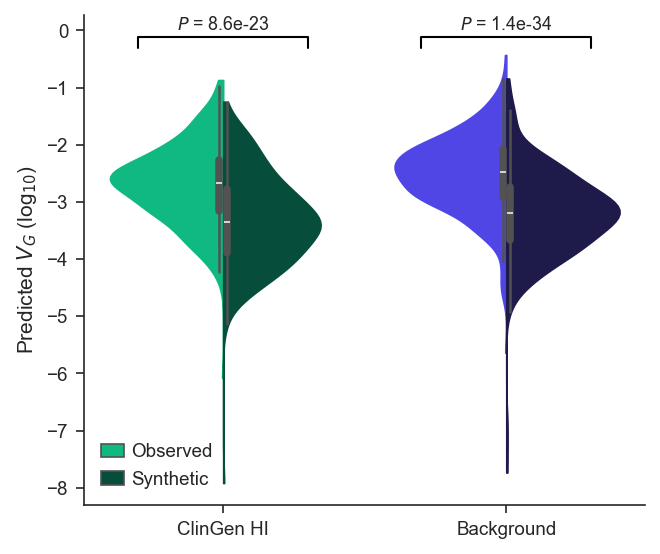

In [8]:
# ── Fig: Observed gnomAD Vg vs synthetic null — split violin ─────────────────
_sv_long = []
for _key, _df_r, _df_s in [
    ('clingen',    df_hi,  df_hi_synth),
    ('background', df_bg,  df_bg_synth),
]:
    _grp = DISPLAY_NAMES[_key]
    for v in _df_r['vg_predicted'].drop_nulls().to_list():
        _sv_long.append({'group': _grp, 'type': 'Observed', 'vg': v})
    for v in _df_s['vg_predicted_perm'].drop_nulls().to_list():
        _sv_long.append({'group': _grp, 'type': 'Synthetic', 'vg': v})

_sv_df = pd.DataFrame(_sv_long)
_sv_df['log_vg'] = np.log10(np.maximum(_sv_df['vg'], 1e-12))

# Mann-Whitney U (one-sided: observed > synthetic)
_mw = {}
for _key in ['clingen', 'background']:
    _grp = DISPLAY_NAMES[_key]
    _obs = _sv_df[(_sv_df['group'] == _grp) & (_sv_df['type'] == 'Observed')]['log_vg']
    _syn = _sv_df[(_sv_df['group'] == _grp) & (_sv_df['type'] == 'Synthetic')]['log_vg']
    _, _p = stats.mannwhitneyu(_obs, _syn, alternative='greater')
    _mw[_grp] = (_p, len(_obs), len(_syn))
    print(f'{_grp}: U P = {_p:.2e}  (n_obs={len(_obs)}, n_syn={len(_syn)})')

_order     = [DISPLAY_NAMES['clingen'], DISPLAY_NAMES['background']]
_hue_order = ['Observed', 'Synthetic']
# placeholder — recolored post-hoc per group using SOURCE_PALETTE
_hue_pal   = {'Observed': '#cccccc', 'Synthetic': '#888888'}

with autosave('Fig_Vg_observed_vs_synthetic', notebook=NOTEBOOK_NAME):
    with sns.axes_style('ticks'):
        fig, ax = plt.subplots(figsize=(4.5, 3.8))

        sns.violinplot(
            data=_sv_df, x='group', y='log_vg',
            hue='type', hue_order=_hue_order, order=_order,
            split=True, cut=0, inner='box',
            palette=_hue_pal, linewidth=0.8,
            ax=ax,
        )

        # Recolour violin halves per group using SOURCE_PALETTE
        # Order matches _order: [ClinGen HI Obs, ClinGen HI Synth, Background Obs, Background Synth]
        import matplotlib.collections as _mc
        _violin_colors = [
            SOURCE_PALETTE['clingen'],
            SOURCE_PALETTE['clingen_null'],
            SOURCE_PALETTE['background'],
            SOURCE_PALETTE['background_null'],
        ]
        _vpolys = [c for c in ax.collections if isinstance(c, _mc.PolyCollection)]
        for _poly, _col in zip(_vpolys, _violin_colors):
            _poly.set_facecolor(_col)
            _poly.set_edgecolor(_col)

        # Significance brackets spanning each split violin
        _y_top = _sv_df['log_vg'].max()
        _h     = (_sv_df['log_vg'].max() - _sv_df['log_vg'].min()) * 0.07
        for xi, _key in enumerate(['clingen', 'background']):
            _grp          = DISPLAY_NAMES[_key]
            _p, _no, _ns  = _mw[_grp]
            _y            = _y_top + _h * 0.6
            _tip          = _y   - _h * 0.35
            ax.plot(
                [xi - 0.3, xi - 0.3, xi + 0.3, xi + 0.3],
                [_tip, _y, _y, _tip],
                color='k', lw=1.0,
            )
            ax.text(
                xi, _y + _h * 0.1,
                f'$P$ = {_p:.1e}',
                ha='center', va='bottom', fontsize=8.5,
            )

        ax.set_xlabel('')
        ax.set_ylabel('Predicted $V_G$ (log$_{10}$)', fontsize=10)
        ax.tick_params(labelsize=9, direction='out', length=4)
        ax.legend(title='', frameon=False, fontsize=9,
                  handlelength=1.2, handletextpad=0.4)
        # Recolour legend handles after legend is set (Observed=clingen, Synthetic=clingen_null)
        for _h, _c in zip(ax.get_legend().legend_handles,
                          [SOURCE_PALETTE['clingen'], SOURCE_PALETTE['clingen_null']]):
            _h.set_facecolor(_c)
        sns.despine(ax=ax)
        plt.tight_layout()


[save_plot] Saved: final_figure_Fig_Vg_Observed_vs_Synthetic_Boxplot_14032026_1230.pdf
[save_plot] Saved: final_figure_Fig_Vg_Observed_vs_Synthetic_Boxplot_14032026_1230.svg


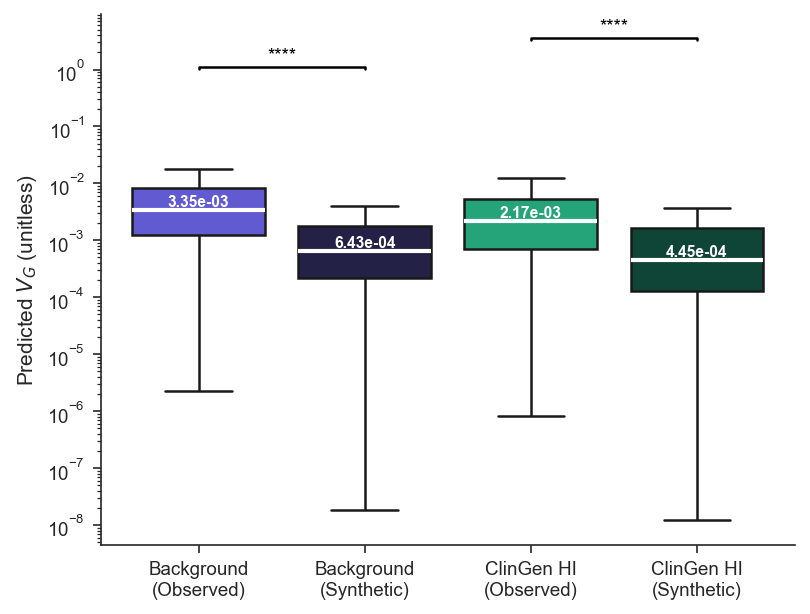

In [9]:
# ── Fig: Vg_predicted — Observed vs Synthetic null (boxplot) ─────────────────
_VG_PLOT_LABELS = {
    'background':      'Background\n(Observed)',
    'background_null': 'Background\n(Synthetic)',
    'clingen':         'ClinGen HI\n(Observed)',
    'clingen_null':    'ClinGen HI\n(Synthetic)',
}
_VG_ORDER     = ['background', 'background_null', 'clingen', 'clingen_null']

_vg_box = (
    pl.concat([
        df_hi.select(['source', 'vg_predicted']).rename({'vg_predicted': 'vg'}),
        df_hi_synth.select(['source', 'vg_predicted_perm']).rename({'vg_predicted_perm': 'vg'}),
        df_bg.select(['source', 'vg_predicted']).rename({'vg_predicted': 'vg'}),
        df_bg_synth.select(['source', 'vg_predicted_perm']).rename({'vg_predicted_perm': 'vg'}),
    ])
    .drop_nulls()
    .filter(pl.col('vg') > 0)
    .to_pandas()
)
_vg_box['label']   = _vg_box['source'].map(_VG_PLOT_LABELS)
_box_order         = [_VG_PLOT_LABELS[s] for s in _VG_ORDER]
_palette_by_label  = {_VG_PLOT_LABELS[s]: SOURCE_PALETTE[s] for s in _VG_ORDER}

def _p_stars(p):
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 0.05: return '*'
    return 'ns'

def _box_sig_brackets(ax, data, x_col, y_col, order, pairs):
    y_max = data[y_col].max()
    level, step = y_max * 3.0, 3.2        # log-space steps
    for idx, (a, b) in enumerate(pairs):
        va = data.loc[data[x_col] == a, y_col].dropna()
        vb = data.loc[data[x_col] == b, y_col].dropna()
        if len(va) < 3 or len(vb) < 3:
            continue
        _, p = stats.mannwhitneyu(va, vb, alternative='two-sided')
        x1, x2 = order.index(a), order.index(b)
        y = level * (step ** idx)
        ax.plot([x1, x1, x2, x2], [y / 1.08, y, y, y / 1.08], lw=1.2, c='black')
        ax.text((x1 + x2) / 2, y * 1.10, _p_stars(p),
                ha='center', va='bottom', fontsize=9, color='black')

def _box_annotate_medians(ax, data, x_col, y_col, order):
    medians = data.groupby(x_col)[y_col].median()
    for idx, cat in enumerate(order):
        if cat not in medians.index:
            continue
        v = medians[cat]
        ax.text(idx, v * 1.06, f'{v:.2e}',
                ha='center', va='bottom', fontsize=7.5,
                color='white', fontweight='bold', zorder=6)

with autosave('Fig_Vg_Observed_vs_Synthetic_Boxplot', notebook=NOTEBOOK_NAME):
    with sns.axes_style('ticks'):
        fig, ax = plt.subplots(figsize=(5.5, 4.2))

        sns.boxplot(
            data=_vg_box,
            x='label', y='vg',
            hue='label',
            order=_box_order,
            hue_order=_box_order,
            palette=_palette_by_label,
            dodge=False,
            legend=False,
            showfliers=False,
            medianprops={'color': 'white', 'linewidth': 2.0},
            whiskerprops={'linewidth': 1.2},
            boxprops={'linewidth': 1.2},
            capprops={'linewidth': 1.2},
            ax=ax,
        )
        ax.set_yscale('log')
        _box_annotate_medians(ax, _vg_box, 'label', 'vg', _box_order)
        _box_sig_brackets(
            ax, _vg_box, 'label', 'vg', _box_order,
            pairs=[
                (_VG_PLOT_LABELS['background'],  _VG_PLOT_LABELS['background_null']),
                (_VG_PLOT_LABELS['clingen'],      _VG_PLOT_LABELS['clingen_null']),
            ],
        )

        ax.set_xlabel('')
        ax.set_ylabel('Predicted $V_G$ (unitless)', fontsize=10)
        ax.tick_params(labelsize=9, direction='out', length=4)
        sns.despine(ax=ax)
        plt.tight_layout()


[save_plot] Saved: final_figure_Fig_AF_Depletion_Rare_vs_Common_SplitViolin_14032026_1230.pdf
[save_plot] Saved: final_figure_Fig_AF_Depletion_Rare_vs_Common_SplitViolin_14032026_1230.svg


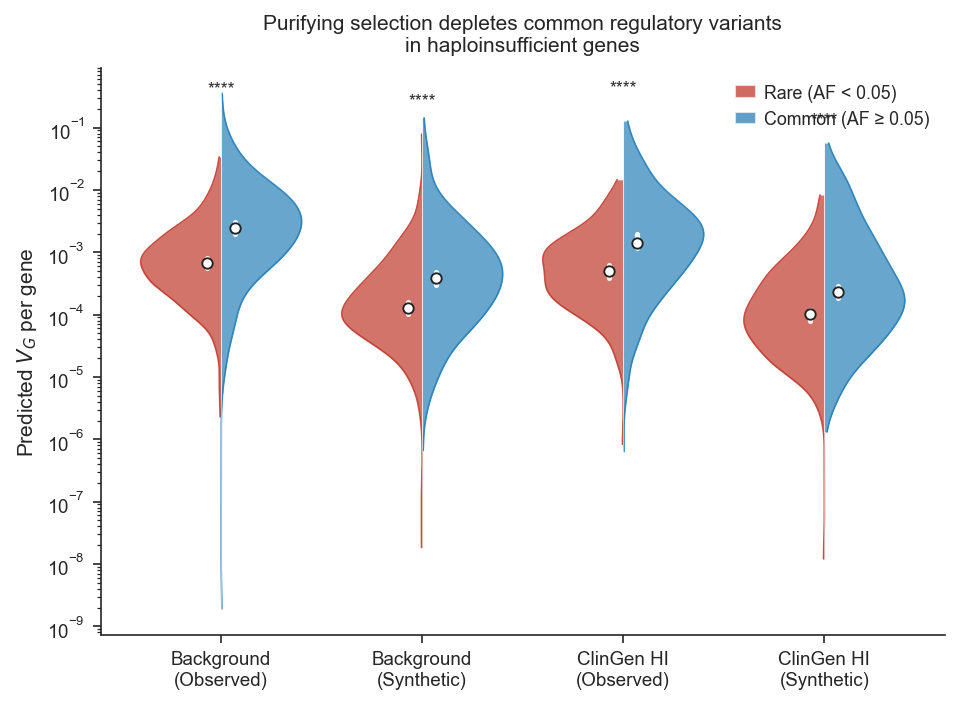

In [10]:
# ── Fig: AF depletion — Rare vs Common Vg split violin ──────────────────────
# Purifying selection depletes high-impact common variants (AF ≥ 0.05),
# especially in haploinsufficient ClinGen HI genes.

_AF_SRC_LABELS = {
    'background':      'Background\n(Observed)',
    'background_null': 'Background\n(Synthetic)',
    'clingen':         'ClinGen HI\n(Observed)',
    'clingen_null':    'ClinGen HI\n(Synthetic)',
}
_AF_SRC_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']

_af_parts = []
for _src_key, _df in [
    ('background',      df_bg),
    ('background_null', df_bg_synth),
    ('clingen',         df_hi),
    ('clingen_null',    df_hi_synth),
]:
    _is_synth = _src_key.endswith('_null')
    _rare_col = 'vg_rare_perm'      if _is_synth else 'vg_rare'
    _comm_col = 'vg_common_perm'    if _is_synth else 'vg_common'
    _tot_col  = 'vg_predicted_perm' if _is_synth else 'vg_predicted'
    _af_parts.append(
        _df.select([
            pl.lit(_src_key).alias('source'),
            pl.col(_tot_col).alias('vg_total'),
            pl.col(_rare_col).alias('vg_rare'),
            pl.col(_comm_col).alias('vg_common'),
        ]).filter(pl.col('vg_total') > 0)
    )

_af_df = pl.concat(_af_parts, how='diagonal_relaxed').to_pandas()
_af_df['label'] = _af_df['source'].map(_AF_SRC_LABELS)
_af_label_order = [_AF_SRC_LABELS[s] for s in _AF_SRC_ORDER]

_RARE_COLOR   = '#C0392B'   # deep red
_COMMON_COLOR = '#2980B9'   # steel blue


def _bstrap_med_ci(arr, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    meds = np.array([np.median(rng.choice(arr, len(arr), replace=True)) for _ in range(n_boot)])
    return np.median(arr), np.percentile(meds, 2.5), np.percentile(meds, 97.5)


def _manual_split_violin(ax, data, x_col, y_col, hue_col, x_order,
                         left_hue, right_hue,
                         left_color, right_color,
                         width=0.38, bw_method='silverman', alpha=0.72):
    from scipy.stats import gaussian_kde
    for xi, x_cat in enumerate(x_order):
        for hue_cat, color, sign in [
            (left_hue,  left_color,  -1),
            (right_hue, right_color, +1),
        ]:
            vals = data.loc[(data[x_col] == x_cat) & (data[hue_col] == hue_cat), y_col].dropna().values
            vals = vals[vals > 0]
            if len(vals) < 5:
                continue
            log_vals = np.log10(vals)
            kde = gaussian_kde(log_vals, bw_method=bw_method)
            y_log_grid = np.linspace(log_vals.min(), log_vals.max(), 300)
            density = kde(y_log_grid)
            density_norm = density / density.max() * width
            y_grid = 10 ** y_log_grid
            x_base = np.full_like(y_grid, xi)
            x_fill = x_base + sign * density_norm
            ax.fill_betweenx(y_grid, x_base, x_fill,
                             color=color, alpha=alpha, linewidth=0)
            ax.plot(x_fill, y_grid, color=color, lw=0.8, alpha=0.9)
            ax.plot(x_base, y_grid, color='white', lw=0.5, alpha=0.5)


def _overlay_median_ci(ax, data, x_col, y_col, hue_col, x_order,
                       left_hue, right_hue, offsets=(-0.07, 0.07)):
    for xi, x_cat in enumerate(x_order):
        for hue_cat, x_off in [(left_hue, offsets[0]), (right_hue, offsets[1])]:
            vals = data.loc[(data[x_col] == x_cat) & (data[hue_col] == hue_cat), y_col].dropna().values
            vals = vals[vals > 0]
            if len(vals) < 5:
                continue
            med, lo, hi = _bstrap_med_ci(vals)
            # CI bar
            ax.plot([xi + x_off, xi + x_off], [lo, hi],
                    '-', lw=2.5, color='white', alpha=0.9, zorder=9,
                    solid_capstyle='round')
            # Median dot
            ax.plot([xi + x_off], [med], 'o', ms=5.0, color='white',
                    markeredgecolor='#222222', markeredgewidth=0.9, zorder=10)


with autosave('Fig_AF_Depletion_Rare_vs_Common_SplitViolin', notebook=NOTEBOOK_NAME):
    with sns.axes_style('ticks'):
        fig, ax = plt.subplots(figsize=(6.5, 4.8))

        _RARE_LABEL   = 'Rare (AF < 0.05)'
        _COMMON_LABEL = 'Common (AF \u2265 0.05)'

        _af_long_plot = _af_df[(_af_df['vg_rare'] > 0) | (_af_df['vg_common'] > 0)].melt(
            id_vars=['source', 'label'],
            value_vars=['vg_rare', 'vg_common'],
            var_name='af_class', value_name='vg',
        )
        _af_long_plot['af_class'] = _af_long_plot['af_class'].map(
            {'vg_rare': _RARE_LABEL, 'vg_common': _COMMON_LABEL}
        )
        _af_long_plot = _af_long_plot[_af_long_plot['vg'] > 0].copy()

        _manual_split_violin(
            ax, _af_long_plot, 'label', 'vg', 'af_class', _af_label_order,
            left_hue=_RARE_LABEL, right_hue=_COMMON_LABEL,
            left_color=_RARE_COLOR, right_color=_COMMON_COLOR,
            width=0.40, alpha=0.70,
        )
        _overlay_median_ci(
            ax, _af_long_plot, 'label', 'vg', 'af_class', _af_label_order,
            left_hue=_RARE_LABEL, right_hue=_COMMON_LABEL,
            offsets=(-0.07, 0.07),
        )

        # MWU significance: rare vs common within each gene set
        for xi, x_cat in enumerate(_af_label_order):
            _r = _af_df.loc[_af_df['label'] == x_cat, 'vg_rare'].dropna().values
            _c = _af_df.loc[_af_df['label'] == x_cat, 'vg_common'].dropna().values
            _r, _c = _r[_r > 0], _c[_c > 0]
            if len(_r) < 3 or len(_c) < 3:
                continue
            _, _p = stats.mannwhitneyu(_r, _c, alternative='two-sided')
            _stars = _p_stars(_p)
            _y_top = max(np.percentile(_r, 99), np.percentile(_c, 99)) * 4.5
            ax.text(xi, _y_top, _stars, ha='center', va='bottom',
                    fontsize=8.5, color='#333333')

        ax.set_yscale('log')
        ax.set_xlim(-0.6, len(_af_label_order) - 0.4)
        ax.set_xticks(range(len(_af_label_order)))
        ax.set_xticklabels(_af_label_order, fontsize=9)
        ax.set_xlabel('', fontsize=10)
        ax.set_ylabel('Predicted $V_G$ per gene', fontsize=10)
        ax.tick_params(labelsize=9, direction='out', length=4)

        # Manual legend
        from matplotlib.patches import Patch
        _legend_handles = [
            Patch(facecolor=_RARE_COLOR,   alpha=0.75, label='Rare (AF < 0.05)'),
            Patch(facecolor=_COMMON_COLOR, alpha=0.75, label='Common (AF \u2265 0.05)'),
        ]
        ax.legend(handles=_legend_handles, frameon=False,
                  fontsize=8.5, handlelength=1.2, handletextpad=0.4,
                  loc='upper right')

        ax.set_title(
            'Purifying selection depletes common regulatory variants\n'
            'in haploinsufficient genes',
            fontsize=10, pad=8,
        )
        sns.despine(ax=ax)
        plt.tight_layout()


In [11]:
# ── Stats: AF depletion — exact values for thesis text ───────────────────────
import pandas as pd

_stats_rows = []
for _src_key, _df in [
    ('background',      df_bg),
    ('background_null', df_bg_synth),
    ('clingen',         df_hi),
    ('clingen_null',    df_hi_synth),
]:
    _is_synth = _src_key.endswith('_null')
    _rare_col = 'vg_rare_perm'      if _is_synth else 'vg_rare'
    _comm_col = 'vg_common_perm'    if _is_synth else 'vg_common'
    _tot_col  = 'vg_predicted_perm' if _is_synth else 'vg_predicted'
    _sub = (
        _df.select([_rare_col, _comm_col, _tot_col])
        .drop_nulls()
        .filter(pl.col(_tot_col) > 0)
        .to_pandas()
    )
    _rare = _sub[_rare_col].values
    _comm = _sub[_comm_col].values
    _r_pos = _rare[_rare > 0]
    _c_pos = _comm[_comm > 0]
    _, _p = stats.mannwhitneyu(_r_pos, _c_pos, alternative='two-sided')
    _stats_rows.append({
        'gene_set':          _AF_SRC_LABELS[_src_key],
        'n_genes':           len(_sub),
        'med_vg_rare':       np.median(_r_pos),
        'med_vg_common':     np.median(_c_pos),
        'common_rare_ratio': np.median(_c_pos) / np.median(_r_pos),
        'med_common_frac':   np.median(_comm / (_sub[_tot_col].values + 1e-30)),
        'mwu_p':             _p,
    })

_stats_df = pd.DataFrame(_stats_rows).set_index('gene_set')

# Pct reduction in median common Vg: Background Observed → ClinGen HI Observed
_bg_comm  = _stats_df.loc['Background\n(Observed)',  'med_vg_common']
_hi_comm  = _stats_df.loc['ClinGen HI\n(Observed)',  'med_vg_common']
_pct_drop = 100 * (1 - _hi_comm / _bg_comm)

print("=== Median Vg by AF class ===")
print(_stats_df[['n_genes','med_vg_rare','med_vg_common','common_rare_ratio','mwu_p']].to_string())
print(f"\nCommon Vg reduction (Background → ClinGen HI, observed): {_pct_drop:.1f}%")
print(f"  Background Observed common:  {_bg_comm:.3e}")
print(f"  ClinGen HI Observed common:  {_hi_comm:.3e}")


=== Median Vg by AF class ===
                         n_genes  med_vg_rare  med_vg_common  common_rare_ratio         mwu_p
gene_set                                                                                     
Background\n(Observed)       349     0.000682       0.002472           3.622534  3.225438e-24
Background\n(Synthetic)      349     0.000130       0.000394           3.034166  5.987755e-13
ClinGen HI\n(Observed)       316     0.000502       0.001398           2.784746  5.029267e-13
ClinGen HI\n(Synthetic)      316     0.000103       0.000228           2.225707  3.246493e-09

Common Vg reduction (Background → ClinGen HI, observed): 43.4%
  Background Observed common:  2.472e-03
  ClinGen HI Observed common:  1.398e-03
